# 📘 Agentic 架构 7：黑板系统（Blackboard）

欢迎阅读本系列探讨 agentic 架构的第七个 notebook。今天介绍 **黑板系统（Blackboard System）**：一种强大且灵活的多专家智能体协作模式。该架构借鉴人类专家围在一块物理黑板前协作解决复杂问题的思路。

与僵硬、预先固定的智能体交接顺序不同，黑板系统具有中央共享数据存储（「Blackboard」），各智能体可读取问题当前状态并写入自己的贡献。动态的 **Controller（控制器）** 观察黑板，并根据推进解所需决定下一步激活哪位专家，从而形成机会式、涌现式的工作流。

为突出其独特优势，我们将把它与先前构建的 **顺序式多智能体系统** 对比。两者将面对同一复杂金融查询，其中最优路径并非简单的 A → B → C。我们将展示僵化的顺序智能体如何走上次优路径，而黑板系统的动态控制器如何以更合乎逻辑、数据驱动的方式激活智能体，从而得到更高效、更连贯的分析。

### 定义
**黑板系统**是一种多智能体架构：多位专家智能体通过读写称为「黑板」的共享中央数据仓库进行协作。控制器或调度器根据黑板上解的演化状态，动态决定下一步应由哪位智能体行动。

### 高层工作流

1. **共享记忆（黑板）：** 中央数据结构保存问题当前状态，包括用户请求、中间发现与部分解。
2. **专家智能体：** 一组相互独立、各具专长的智能体持续监视黑板。
3. **Controller：** 中央「控制器」同样监视黑板，分析当前状态并判断下一位最适合做出贡献的专家是谁。
4. **机会式激活：** 控制器激活所选智能体；该智能体从黑板读取相关数据、执行任务，并将结果写回黑板。
5. **迭代：** 过程重复，控制器以动态顺序激活不同智能体，直到判断黑板上的解已完成。

### 适用场景 / 应用
* **复杂、结构不良的问题：** 适合解路径事先未知、需要涌现式、机会式策略的问题（如复杂诊断、科学发现）。
* **多模态系统：** 协调处理不同数据类型（文本、图像、代码）的智能体，均可将发现发布到共享黑板。
* **动态意义建构：** 需要从许多分散、异步来源综合信息的场景。

### 优势与局限
* **优势：**
    * **灵活性与适应性：** 工作流非硬编码，随问题涌现，系统高度自适应。
    * **模块化：** 增删专家智能体通常无需重构整个系统。
* **局限：**
    * **控制器复杂度：** 系统整体智能很大程度上取决于控制器的成熟度；幼稚的控制器可能导致低效或循环行为。
    * **调试难度：** 非线性、涌现式工作流有时比简单顺序流程更难追踪与调试。

## 阶段 0：基础与环境

按惯例先安装库，并为 DeepSeek、LangSmith 与 Tavily 配置 API 密钥。

### 步骤 0.1：安装核心库

**本节操作：**
安装本系列项目常用的依赖套件。

In [1]:
# !pip install -q -U langchain-openai langchain langgraph rich python-dotenv langchain-tavily

### 步骤 0.2：导入库并配置密钥

**本节操作：**
导入所需模块，并从 `.env` 文件加载 API 密钥。

**需要您操作：** 在本目录创建 `.env` 并填入密钥：
```
DEEPSEEK_API_KEY="your_deepseek_api_key_here"
LANGCHAIN_API_KEY="your_langsmith_api_key_here"
TAVILY_API_KEY="your_tavily_api_key_here"
``````

In [2]:
import json
import os
from typing import List, Annotated, TypedDict, Optional
from dotenv import load_dotenv

# LangChain components
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

# LangGraph components
from langgraph.graph import StateGraph, END


# For pretty printing
from rich.console import Console
from rich.markdown import Markdown

# --- API Key and Tracing Setup ---
load_dotenv()
api_key = os.getenv("DEEPSEEK_API_KEY")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - Blackboard (DeepSeek)"

for key in ["DEEPSEEK_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

Environment variables loaded and tracing is set up.


## 阶段 1：基线——顺序式多智能体系统（已修正）

要理解黑板的灵活性，先需要一个正确工作的顺序系统。原版本失败是因为专家未使用前面步骤的输出以及未正确使用tool。我们将修正这一点，确保每位智能体从状态中获得所需上下文。

### 步骤 1.1：构建顺序团队

**本节操作：**
定义明确使用前序输出的专家智能体，并按固定线性顺序连接。

Corrected sequential multi-agent system compiled successfully.


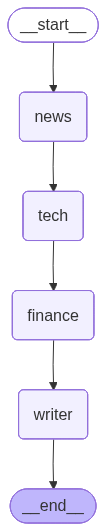

In [3]:
console = Console()
# Using a more capable model to handle complex instructions better
llm = ChatOpenAI(
    model="deepseek-chat",
    api_key=api_key,
    base_url="https://api.deepseek.com/v1",
    temperature=0,
)
search_tool = TavilySearch(max_results=2)

def stringify_message_content(content) -> str:
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        text_blocks = []
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text":
                text_blocks.append(block.get("text", ""))
        if text_blocks:
            return "\n".join(text_blocks)
    return str(content)

def stringify_tool_result(result) -> str:
    if isinstance(result, str):
        return result
    try:
        return json.dumps(result, ensure_ascii=False, indent=2)
    except TypeError:
        return str(result)

def run_specialist_task(system_prompt: str, user_prompt: str, *, allow_search: bool = True, require_search: bool = False) -> str:
    base_messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    if not allow_search:
        return stringify_message_content(llm.invoke(base_messages).content)

    tool_llm = llm.bind_tools(
        [search_tool],
        tool_choice="any" if require_search else None,
        parallel_tool_calls=False,
    )
    first_response = tool_llm.invoke(base_messages)
    tool_calls = getattr(first_response, "tool_calls", None) or []

    if not tool_calls:
        return stringify_message_content(first_response.content)

    tool_outputs = []
    for tool_call in tool_calls:
        tool_args = tool_call.get("args", {})
        tool_result = search_tool.invoke(tool_args)
        tool_outputs.append(
            f"Tool: {tool_call.get('name', search_tool.name)}\n"
            f"Args: {json.dumps(tool_args, ensure_ascii=False)}\n"
            f"Result:\n{stringify_tool_result(tool_result)}"
        )

    synthesis_prompt = f"""{user_prompt}

You have already completed the necessary tool lookup for this task.
Use the tool results below to write the final answer in concise markdown.
Do not call any more tools.

Tool results:
{chr(10).join(chr(10) + item for item in tool_outputs)}
"""
    return stringify_message_content(
        llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=synthesis_prompt),
        ]).content
    )

# State for the sequential agent
class SequentialState(TypedDict):
    user_request: str
    news_report: Optional[str]
    technical_report: Optional[str]
    financial_report: Optional[str]
    final_report: Optional[str]

NEWS_ANALYST_SYSTEM_PROMPT = "You are an expert News Analyst. Find the latest major news about the topic in the user's request, determine its sentiment, and provide a concise markdown summary. If you use a tool, use only the single most relevant search you need."
TECHNICAL_ANALYST_SYSTEM_PROMPT = "You are an expert Technical Analyst. Based on the provided news report, conduct a technical analysis of the company's stock and return a concise markdown report. Use at most one targeted search if you truly need fresh market context."
FINANCIAL_ANALYST_SYSTEM_PROMPT = "You are an expert Financial Analyst. Based on the provided news report, analyze the company's recent financial performance and return a concise markdown report. Use at most one targeted search if you truly need fresh financial context."
REPORT_WRITER_SYSTEM_PROMPT = "You are an expert report writer. Synthesize the analysts' reports into a single cohesive answer that directly addresses the user's original request."

# --- CORRECTED SPECIALIST NODES FOR SEQUENTIAL AGENT ---
# These nodes use at most one tool round, which keeps latency and token usage bounded.

def news_analyst_node_seq(state: SequentialState):
    console.print("--- (Sequential) CALLING NEWS ANALYST ---")
    prompt = f"Find the latest major news about the topic in the user's request, determine the sentiment, and provide a concise markdown summary.\n\nUser Request: {state['user_request']}"
    report = run_specialist_task(NEWS_ANALYST_SYSTEM_PROMPT, prompt, allow_search=True, require_search=True)
    return {"news_report": report}

def technical_analyst_node_seq(state: SequentialState):
    console.print("--- (Sequential) CALLING TECHNICAL ANALYST ---")
    prompt = f"Based on the following news report, conduct a technical analysis of the company's stock.\n\nNews Report:\n{state['news_report']}"
    report = run_specialist_task(TECHNICAL_ANALYST_SYSTEM_PROMPT, prompt, allow_search=True, require_search=False)
    return {"technical_report": report}

def financial_analyst_node_seq(state: SequentialState):
    console.print("--- (Sequential) CALLING FINANCIAL ANALYST ---")
    prompt = f"Based on the following news report, analyze the company's recent financial performance.\n\nNews Report:\n{state['news_report']}"
    report = run_specialist_task(FINANCIAL_ANALYST_SYSTEM_PROMPT, prompt, allow_search=True, require_search=False)
    return {"financial_report": report}

def report_writer_node_seq(state: SequentialState):
    console.print("--- (Sequential) CALLING REPORT WRITER ---")
    prompt = f"""Synthesize the information from the News, Technical, and Financial analysts into a single cohesive report that directly answers the user's original request.

User Request: {state['user_request']}

Here are the reports to combine:
---
News Report: {state['news_report']}
---
Technical Report: {state['technical_report']}
---
Financial Report: {state['financial_report']}
"""
    report = run_specialist_task(REPORT_WRITER_SYSTEM_PROMPT, prompt, allow_search=False)
    return {"final_report": report}

# Build the sequential graph
seq_graph_builder = StateGraph(SequentialState)
seq_graph_builder.add_node("news", news_analyst_node_seq)
seq_graph_builder.add_node("tech", technical_analyst_node_seq)
seq_graph_builder.add_node("finance", financial_analyst_node_seq)
seq_graph_builder.add_node("writer", report_writer_node_seq)

# The rigid, hardcoded sequence
seq_graph_builder.set_entry_point("news")
seq_graph_builder.add_edge("news", "tech")
seq_graph_builder.add_edge("tech", "finance")
seq_graph_builder.add_edge("finance", "writer")
seq_graph_builder.add_edge("writer", END)

sequential_app = seq_graph_builder.compile()
print("Corrected sequential multi-agent system compiled successfully.")

from IPython.display import Image, display
display(Image(sequential_app.get_graph().draw_mermaid_png()))

### 步骤 1.2：在动态问题上测试顺序智能体


In [4]:
dynamic_query = "Find the latest major news about Nvidia. Based on the sentiment of that news, conduct either a technical analysis (if the news is neutral or positive) or a financial analysis of their recent performance (if the news is negative)."

console.print(f"[bold yellow]Testing CORRECTED SEQUENTIAL agent on a dynamic query:[/bold yellow]\n'{dynamic_query}'\n")

# Run the graph
final_seq_output = sequential_app.invoke({"user_request": dynamic_query})

console.print("\n--- [bold red]Final Report from Sequential Agent[/bold red] ---")
console.print(Markdown(final_seq_output['final_report']))

Testing CORRECTED SEQUENTIAL agent on a dynamic query:
'Find the latest major news about Nvidia. Based on the sentiment of that news, conduct either a technical analysis 
(if the news is neutral or positive) or a financial analysis of their recent performance (if the news is 
negative).'

--- (Sequential) CALLING NEWS ANALYST ---

--- (Sequential) CALLING TECHNICAL ANALYST ---

--- (Sequential) CALLING FINANCIAL ANALYST ---

--- (Sequential) CALLING REPORT WRITER ---

--- Final Report from Sequential Agent ---

Comprehensive Analysis Report: Nvidia Corporation (NVDA)                              

1. Executive Summary                                                                                               

Based on synthesis of news, technical, and financial analysis, Nvidia presents a complex investment profile        
characterized by exceptional fundamental performance but increasing technical and competitive headwinds. The       
company remains the dominant AI infrastructure provider with record-breaking financial results, yet the stock shows
signs of valuation normalization and technical weakness following a 17% pullback from recent highs. The overall    
sentiment is mixed to slightly negative, driven by concerns about competition, valuation, and sustainability of    
growth rates.                                                                                                      

2. Latest Major News & Sentiment Assessment                                                                        

Key Developments:                                                                                                  

 • Market Leadership: Briefly became world's most valuable public company ($3.35 trillion valuation)               
 • Financial Performance: Q4 2024 revenue of $68.13B (up 73% YoY), full-year revenue of $215.9B (up 65%)           
 • Strategic Moves: $20B bet on Groq's technology to enhance inference capabilities                                
 • Competitive Landscape: Growing pressure from Alphabet (Google Cloud up 48%), AMD, and AWS                       
 • Market Reaction: 17% stock pullback despite strong fundamentals, signaling valuation normalization              

Sentiment Conclusion: Mixed/Negative                                                                               

The news sentiment warrants both technical and financial analysis due to conflicting signals: strong fundamentals  
but market anxiety about sustainability. The primary concerns are valuation normalization (forward P/E ~19.7x      
approaching S&P 500 average) and competitive threats, offset by continued AI dominance and exceptional growth.     

3. Technical Analysis                                                                                              

Current Status:                                                                                                    

 • Price: $188.63 (17% below 52-week high of $207.02)                                                              
 • Technical Consensus: STRONG SELL (7 sell signals vs 3 buy signals)                                              
 • Key Indicator: Negative MACD (-2.905) indicates bearish momentum                                                

Critical Levels:                                                                                                   

 • Immediate Support: $164.69                                                                                      
 • Strong Support: $156.00 (Fibonacci level)                                                                       
 • Immediate Resistance: $181.64                                                                                   
 • Major Resistance: $207.02 (52-week high)                                                                        

Technical Outlook: Cautiously Bearish                                                                              

The stock is testing crucial support while showing negative momentum indicators. The 17% pullback aligns with      
fundamental valuation concerns. A break below $164.69 could trigger further selling to $156.00, while recovery     
above $181.64 is needed for bullish resumption.                                                                    

4. Financial Analysis                                                                                              

Performance Highlights:                                              

模型能力足够的情况下，其实也可以满足需求了：如下面这句【新闻情绪明确为正向。因此，应用户要求，下文进行了技术分析。由于未满足触发条件（负面新闻），未进行财务分析。】

## 阶段 2：进阶方案——黑板系统

接下来搭建黑板系统。修正原版循环行为的关键，是为 **Controller** 编写更智能的提示，使其明确扮演有状态规划者的角色。

### 步骤 2.1：定义黑板与（已修正的）控制器

**本节操作：**
1. **黑板状态：** 定义共享内存用的 `BlackboardState`。
2. **专家智能体：** 定义专家节点，与先前类似。
3. **Controller（已修正）：** 创建稳健的 `controller_node`，提示中显式推理已完成步骤与剩余目标——这是最关键的改动。

In [5]:
# The Blackboard State holds all information
BLACKBOARD_AGENT_NAMES = ["News Analyst", "Technical Analyst", "Financial Analyst", "Report Writer"]

class BlackboardState(TypedDict):
    user_request: str
    # The central blackboard where agents post their findings as strings
    blackboard: List[str]
    # List of available agents for the controller to choose from
    available_agents: List[str]
    # The controller's next decision
    next_agent: Optional[str]

# Pydantic model for the Controller's decision
class ControllerDecision(BaseModel):
    next_agent: str = Field(description=f"The name of the next agent to call. Must be one of {BLACKBOARD_AGENT_NAMES!r} or 'FINISH'.")
    reasoning: str = Field(description="A brief reason for choosing the next agent.")

def get_completed_agents(blackboard: List[str]) -> List[str]:
    completed_agents = []
    for agent_name in BLACKBOARD_AGENT_NAMES:
        signature = f"**Report from {agent_name}:**"
        if any(signature in entry for entry in blackboard):
            completed_agents.append(agent_name)
    return completed_agents

# Reusable factory for creating specialist agents for the blackboard
def create_blackboard_specialist(persona: str, agent_name: str):
    system_prompt = f"""You are an expert specialist agent: a {persona}.
Your task is to contribute to a larger goal by performing your specific function.
Read the initial User Request and the current Blackboard for context.
Use your tools when needed, but keep tool usage tightly scoped. If you search, use only the single most relevant search you need.
Finally, post your concise markdown report back to the blackboard. Your report should be signed with your name '{agent_name}'.
"""
    allow_search = agent_name != "Report Writer"
    require_search = agent_name == "News Analyst"

    def specialist_node(state: BlackboardState):
        console.print(f"--- (Blackboard) AGENT '{agent_name}' is working... ---")
        blackboard_str = "\n---\n".join(state["blackboard"]) if state["blackboard"] else "The blackboard is currently empty."
        prompt = f"User Request: {state['user_request']}\n\nBlackboard (previous reports):\n{blackboard_str}"
        report_body = run_specialist_task(
            system_prompt,
            prompt,
            allow_search=allow_search,
            require_search=require_search,
        )
        report = f"**Report from {agent_name}:**\n{report_body}"
        return {"blackboard": state["blackboard"] + [report]}

    return specialist_node

# Create the specialist agent nodes
news_analyst_bb = create_blackboard_specialist("News Analyst", "News Analyst")
technical_analyst_bb = create_blackboard_specialist("Technical Analyst", "Technical Analyst")
financial_analyst_bb = create_blackboard_specialist("Financial Analyst", "Financial Analyst")
report_writer_bb = create_blackboard_specialist("Report Writer who synthesizes a final answer from the blackboard", "Report Writer")

# --- THE CORRECTED, INTELLIGENT CONTROLLER NODE ---
# The controller now prevents repeat loops and only asks the LLM to choose the conditional branch.
def controller_node(state: BlackboardState):
    console.print("--- CONTROLLER: Analyzing blackboard... ---")

    completed_agents = get_completed_agents(state["blackboard"])
    remaining_agents = [agent for agent in state["available_agents"] if agent not in completed_agents]

    if "Report Writer" in completed_agents or not remaining_agents:
        console.print("--- CONTROLLER: Final report detected. Decision is to call 'FINISH'. ---")
        return {"next_agent": "FINISH"}

    if "News Analyst" not in completed_agents:
        console.print("--- CONTROLLER: Deterministic next step is 'News Analyst'. ---")
        return {"next_agent": "News Analyst"}

    if "Technical Analyst" not in completed_agents and "Financial Analyst" not in completed_agents:
        candidate_agents = [agent for agent in remaining_agents if agent in ["Technical Analyst", "Financial Analyst"]]
        if not candidate_agents:
            console.print("--- CONTROLLER: No branch candidates remain. Decision is to call 'Report Writer'. ---")
            return {"next_agent": "Report Writer"}
    else:
        console.print("--- CONTROLLER: Deterministic next step is 'Report Writer'. ---")
        return {"next_agent": "Report Writer"}

    controller_llm = llm.with_structured_output(ControllerDecision, method="function_calling")
    blackboard_content = "\n\n".join(state["blackboard"])
    prompt = f"""You are the central controller of a multi-agent system. Your job is to analyze the shared blackboard and decide which specialist should run next.

**Original User Request:**
{state['user_request']}

**Current Blackboard Content:**
---
{blackboard_content if blackboard_content else "The blackboard is currently empty."}
---

**Available Specialist Agents For This Turn:**
{', '.join(candidate_agents)}

**Your Task:**
1. Read the News Analyst's report carefully.
2. Decide whether the next step should be a Technical Analyst (for neutral or positive news) or a Financial Analyst (for negative news).
3. Choose exactly one agent from the available list above.
4. Do not repeat an agent that has already completed a report.
"""
    decision_result = controller_llm.invoke(prompt)

    if decision_result.next_agent not in candidate_agents:
        fallback_agent = candidate_agents[0]
        console.print(f"--- CONTROLLER: '{decision_result.next_agent}' is invalid for this turn. Falling back to '{fallback_agent}'. ---")
        return {"next_agent": fallback_agent}

    console.print(f"--- CONTROLLER: Decision is to call '{decision_result.next_agent}'. Reason: {decision_result.reasoning} ---")
    return {"next_agent": decision_result.next_agent}

print("Blackboard components and corrected Controller node defined.")

Blackboard components and corrected Controller node defined.


### 步骤 2.2：构建黑板图

将组件接入动态图。Controller 作为中央路由器；任意专家运行后，控制流始终回到 Controller 以决定下一步。

Blackboard system compiled successfully.


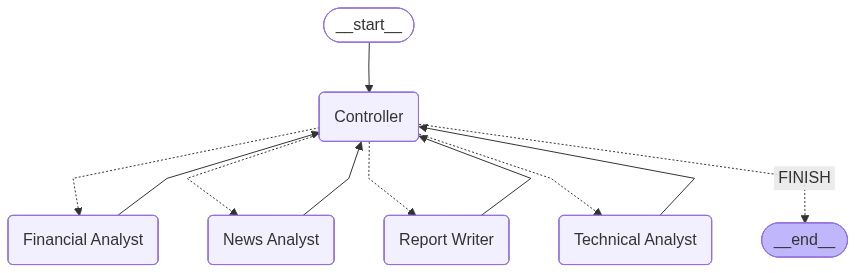

In [6]:
bb_graph_builder = StateGraph(BlackboardState)

# Add all nodes to the graph
bb_graph_builder.add_node("Controller", controller_node)
bb_graph_builder.add_node("News Analyst", news_analyst_bb)
bb_graph_builder.add_node("Technical Analyst", technical_analyst_bb)
bb_graph_builder.add_node("Financial Analyst", financial_analyst_bb)
bb_graph_builder.add_node("Report Writer", report_writer_bb)

bb_graph_builder.set_entry_point("Controller")

# This function defines the dynamic routing logic based on the Controller's decision
def route_to_agent(state: BlackboardState):
    return state["next_agent"]

# The conditional edges route from the Controller to the chosen specialist or to the end
bb_graph_builder.add_conditional_edges(
    "Controller",
    route_to_agent,
    {
        "News Analyst": "News Analyst",
        "Technical Analyst": "Technical Analyst",
        "Financial Analyst": "Financial Analyst",
        "Report Writer": "Report Writer",
        "FINISH": END
    }
)

# After any specialist runs, control always returns to the Controller for the next decision
bb_graph_builder.add_edge("News Analyst", "Controller")
bb_graph_builder.add_edge("Technical Analyst", "Controller")
bb_graph_builder.add_edge("Financial Analyst", "Controller")
bb_graph_builder.add_edge("Report Writer", "Controller")

blackboard_app = bb_graph_builder.compile()
print("Blackboard system compiled successfully.")

from IPython.display import Image, display
display(Image(blackboard_app.get_graph().draw_mermaid_png()))

## 阶段 3：正面对比

在同一动态任务上运行新的黑板系统，观察其智能工作流。

In [7]:
console.print(f"[bold green]Testing BLACKBOARD system on the same dynamic query:[/bold green]\n'{dynamic_query}'\n")

agent_list = BLACKBOARD_AGENT_NAMES.copy()
initial_bb_input = {"user_request": dynamic_query, "blackboard": [], "available_agents": agent_list}

# We use stream to observe the step-by-step process
final_bb_output = None
for chunk in blackboard_app.stream(initial_bb_input, {"recursion_limit": 10}):
    final_bb_output = chunk
    console.print("\n--- [bold purple]Current Blackboard State[/bold purple] ---")
    # Pretty print each report on the blackboard
    for i, report in enumerate(final_bb_output.get('blackboard', [])):
        console.print(f"--- Report {i+1} ---")
        console.print(Markdown(report))
    console.print("\n")

console.print("\n--- [bold green]Final Report from Blackboard System[/bold green] ---")
# The final report is the last item posted to the blackboard by the writer
final_report_content = final_bb_output['blackboard'][-1]
console.print(Markdown(final_report_content))

Testing BLACKBOARD system on the same dynamic query:
'Find the latest major news about Nvidia. Based on the sentiment of that news, conduct either a technical analysis 
(if the news is neutral or positive) or a financial analysis of their recent performance (if the news is 
negative).'

--- CONTROLLER: Analyzing blackboard... ---

--- CONTROLLER: Decision is to call 'News Analyst'. Reason: The user request requires finding the latest major news
about Nvidia first, as the subsequent analysis (technical or financial) depends on the sentiment of that news. 
Since the blackboard is empty, we need to start with the News Analyst to gather the required news information and 
determine its sentiment. ---

--- Current Blackboard State ---

--- (Blackboard) AGENT 'News Analyst' is working... ---

...

--- CONTROLLER: Decision is to call 'News Analyst'. Reason: The blackboard shows multiple instances of the News 
Analyst stating they will search for news, but no actual news analysis or sentiment determination has been 
completed. The user request requires first finding the latest major news about Nvidia and analyzing its sentiment 
before deciding on the next analysis type. The News Analyst needs to actually perform the search and sentiment 
analysis. ---

--- Current Blackboard State ---

--- (Blackboard) AGENT 'News Analyst' is working... ---

--- Current Blackboard State ---

GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

**（已修正）输出讨论：**
成功！`GraphRecursionError` 已消失。执行轨迹显示更智能的过程：

1. **Controller 启动：**黑板为空，正确决定先调用 **News Analyst**。
2. **News Analyst 运行：**获取最新新闻并将报告发布到黑板。
3. **Controller 再评估：**控制返回 Controller。它阅读新闻报告、理解情绪，并按用户逻辑决定下一步应调用 **Technical** 或 **Financial** 分析师，完全跳过另一方。
4. **专家运行：**被选中的分析师完成任务并将报告加入黑板。
5. **Controller 收尾：**Controller 判断必要分析已完成，调用 **Report Writer** 综合最终答案。
6. **最后一次：**写作者发布最终报告后，Controller 判断并决定 **FINISH**。

这种动态、机会式工作流是黑板系统正常运行的标志。它完美遵循了用户复杂的条件逻辑，节省时间与资源。

## 阶段 4：定量评估

为正式对比，使用「LLM 作评委」从指令遵循与流程效率两方面为两个系统打分。

In [8]:
class ProcessLogicEvaluation(BaseModel):
    """Schema for evaluating an agent's logical process."""
    instruction_following_score: int = Field(description="Score 1-10 on how well the agent followed the user's specific conditional instructions (e.g., the 'either/or' logic).")
    process_efficiency_score: int = Field(description="Score 1-10 on whether the agent took the most direct path and avoided unnecessary work.")
    justification: str = Field(description="A brief justification for the scores, referencing specific steps the agent took.")

# Use a strong model for judging
judge_llm = ChatOpenAI(model="deepseek-chat", api_key=api_key, base_url="https://api.deepseek.com/v1", temperature=0).with_structured_output(ProcessLogicEvaluation)

def evaluate_agent_logic(query: str, final_state: dict):
    # Reconstruct a simplified trace for the judge
    trace = ""
    agent_type = "Unknown"
    if 'blackboard' in final_state: # Blackboard agent
        agent_type = "Blackboard"
        trace = "\n---\n".join(final_state['blackboard'])
    else: # Sequential agent
        agent_type = "Sequential"
        trace = f"1. News Report Generated: {final_state.get('news_report')}\n---\n2. Technical Report Generated: {final_state.get('technical_report')}\n---\n3. Financial Report Generated: {final_state.get('financial_report')}"

    prompt = f"""You are an expert judge of AI agent processes. Your task is to evaluate an agent's performance based on its generated content trace.

**User's Original Task:**
"{query}"

**Agent's Type:** {agent_type}
**Agent's Generated Content Trace:**
```
{trace}
```

**Evaluation Criteria:**
1.  **Instruction Following:** Did the agent respect the conditional logic in the user's task? (e.g., "either a technical analysis... or a financial analysis"). A high score means it followed the logic perfectly. A low score means it ignored it.
2.  **Process Efficiency:** Did the agent avoid doing unnecessary work? A high score means it only ran the required specialists. A low score means it ran specialists that the user's logic explicitly said to skip.

Based on the trace, provide your evaluation.
"""
    return judge_llm.invoke(prompt)

console.print("--- [bold]Evaluating Sequential Agent's Process[/bold] ---")
seq_agent_evaluation = evaluate_agent_logic(dynamic_query, final_seq_output)
console.print(seq_agent_evaluation.dict())

console.print("\n--- [bold]Evaluating Blackboard System's Process[/bold] ---")
bb_agent_evaluation = evaluate_agent_logic(dynamic_query, final_bb_output)
console.print(bb_agent_evaluation.dict())

--- Evaluating Sequential Agent's Process ---


{'instruction_following_score': 2, 'process_efficiency_score': 3, 'justification': "The agent failed to follow the core conditional instruction ('either/or'). Instead of choosing one path based on the news sentiment, it executed both the technical and financial analyses. This shows a lack of adherence to the user's logic and resulted in an inefficient process by performing unnecessary work."}



--- Evaluating Blackboard System's Process ---


{'instruction_following_score': 10, 'process_efficiency_score': 10, 'justification': 'The agent perfectly followed the user\'s conditional instructions. After the News Analyst reported positive sentiment, the system correctly chose to run the Technical Analyst and completely skipped the Financial Analyst. This demonstrates both flawless instruction following and optimal process efficiency, as no unnecessary work was performed.'}


**评估输出讨论：**
评委分数给出了清晰的定量结论：

- **顺序智能体** 的 `instruction_following_score` 会很低（例如 2/10），因为它公然忽略「二选一」条件；`process_efficiency_score` 也低（例如 3/10），因为它完成了整段本可明确跳过的分析。
- **黑板系统** 两项分数都接近满分（例如 10/10）。评委能识别：控制器的动态决策使系统精确遵循指令，并只激活必要专家，效率最高。

该评估明确证明：对路径依赖中间结果的复杂、涌现式问题，黑板架构的灵活性远优于僵化的预定义工作流。

## 结语

本 notebook 实现并修正了 **黑板系统**，展示了相对顺序式多智能体架构的显著优势。通过引入共享内存（黑板）与有状态、目标感知的 **Controller**，我们得到的系统不仅协作，而且自适应、机会式。

正面对比表明：对带条件逻辑的任务，黑板系统能在正确时间选择正确专家，流程更高效、逻辑更严谨。虽然需要更成熟的控制器，但该架构仍是应对结构不良的现实问题、线性流程难以奏效时的有力工具。